<a href="https://colab.research.google.com/github/SimbakNetmind/series-de-tiempo/blob/M%C3%A9todos_para_Pron%C3%B3stico_y_Anal%C3%ADtica-Avanzada/02_M%C3%A9todos_de_suavizado_(WMA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de suavizado (WMA)

### Media móvil ponderada (WMA, *Weighted Moving Average*)

* Extensión de la media móvil simple en la que **no todos los datos tienen la misma importancia**.
* En lugar de promediar de forma uniforme, se asignan **pesos diferentes**, normalmente mayores a los valores más recientes (datos recientes contienen más información sobre el futuro).

$$WMA_t = \sum_{i=0}^{k-1} w_i y_{t-i} \quad \text{con} \quad \sum w_i = 1$$

**Donde:**

* $y_{t-i}$: observaciones pasadas.
* $w_i$: pesos.
* $w_0 > w_1 > \dots > w_{k-1}$

---
# Métodos de suavizado (WMA) - Ejemplo práctico

### Configuración de Pesos ($k = 3$):
* $w_0 = 0.5$ (Dato más reciente)
* $w_1 = 0.3$
* $w_2 = 0.2$ (Dato más antiguo)
* $\sum w_i = 1$

### Fórmula Aplicada:
$$WMA_t = \sum_{i=0}^{k-1} w_i y_{t-i}$$

---

### Tabla de cálculos:

| Tiempo ($t$) | Dato ($y_t$) | Cálculo $k = 3$ | WMA |
|:---:|:---:|:---:|:---:|
| 1 | 10 | - | - |
| 2 | 12 | - | - |
| 3 | 13 | 0.5* 13 + 0.3 * 12 + 0.2 * 10 | 12.1 |
| 4 | 16 | 0.5 * 16 + 0.3 *  13 + 0.2 * 12 | 14.3 |
| 5 | 15 | 0.5 * 15 + 0.3 * 16 + 0.2 * 13 | 14.9 |
| 6 | 20 | 0.5 * 20 + 0.3 * 15 + 0.2 * 16 | 17.7 |
| 7 | 22 | 0.5 * 22 + 0.3 * 20 + 0.2 * 15 | 20 |
| 8 | 21 | 0.5 * 21 + 0.3 * 22 + 0.2 * 20 | 21.1 |
| 9 | 23 | 0.5 * 23 + 0.3 * 21 + 0.2 * 22 | 22.2 |
| 10 | 25 | 0.5 * 25 + 0.3 * 23 + 0.2 * 21 | 23.6 |
| 11 | 26 | 0.5 * 26 + 0.3 * 25 + 0.2 * 23 | 25.1 |
| 12 | 28 | 0.5 * 28 + 0.3 * 26 + 0.2 * 25 | 26.8 |
| 13 | 30 | 0.5 * 30 + 0.3 * 28 + 0.2 * 26 | 28.6 |
| 14 | 29 | 0.5 * 29 + 0.3 * 30 + 0.2 * 28 | 29.1 |
| 15 | 31 | 0.5 * 31 + 0.3 * 29 + 0.2 * 30 | 30.2 |
| 16 | 33 |05 * 33 + 0.3 * 31 +0.2 * 29 |31.6|
| 17 | 35 |05 * 35 + 0.3 * 33 +0.2 * 31 |36.6|
| 18 | 36 |05 * 36 + 0.3 * 35 +0.2 * 33 |35.1|
| 19 | 38 |05 * 38 + 0.3 * 36 +0.2 * 35 |36.8|
| 20 | 42 |05 * 42 + 0.3 * 38 +0.2 * 36 |39.6|

---
## 📗 ***Instalación bibliotecas***

In [ ]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q

## 🎯 ***Práctica codigo (WMA)***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Datos
data = [10, 12, 13, 16, 15, 20, 22, 21, 23, 25,
        26, 28, 30, 29, 31, 33, 35, 36, 38, 42]

df = pd.DataFrame({
    'Tiempo (t)': range(1, len(data) + 1),
    'Dato (yt)': data
})

# 2. Configuración WMA
k = 3
weights = np.array([0.2, 0.3, 0.5])


# Generar columna de texto con formato
calculos = []
for i in range(len(data)):
    if i < k - 1:
        calculos.append("-")
    else:
        fórmula = f"0.5*{data[i]} + 0.3*{data[i-1]} + 0.2*{data[i-2]}"
        calculos.append(fórmula)
df['Cálculo k = 3'] = calculos

# Cálculo WMA numérico
wma_vals = df['Dato (yt)'].rolling(window=k).apply(lambda x: np.dot(x, weights), raw=True)
df['WMA'] = wma_vals.apply(lambda x: f"{x:.1f}" if pd.notnull(x) else "-")


# Opción A: Usar to_string con col_space (Define el ancho mínimo de cada columna)
print(df.to_string(index=False, col_space=15, justify='center'))



   Tiempo (t)       Dato (yt)        Cálculo k = 3             WMA      
        1              10                              -          -     
        2              12                              -          -     
        3              13       0.5*13 + 0.3*12 + 0.2*10       12.1     
        4              16       0.5*16 + 0.3*13 + 0.2*12       14.3     
        5              15       0.5*15 + 0.3*16 + 0.2*13       14.9     
        6              20       0.5*20 + 0.3*15 + 0.2*16       17.7     
        7              22       0.5*22 + 0.3*20 + 0.2*15       20.0     
        8              21       0.5*21 + 0.3*22 + 0.2*20       21.1     
        9              23       0.5*23 + 0.3*21 + 0.2*22       22.2     
       10              25       0.5*25 + 0.3*23 + 0.2*21       23.6     
       11              26       0.5*26 + 0.3*25 + 0.2*23       25.1     
       12              28       0.5*28 + 0.3*26 + 0.2*25       26.8     
       13              30       0.5*30 + 0.3*28 + 0

---
## 📈 ***Grafica serie WMA vs Dato Reales***

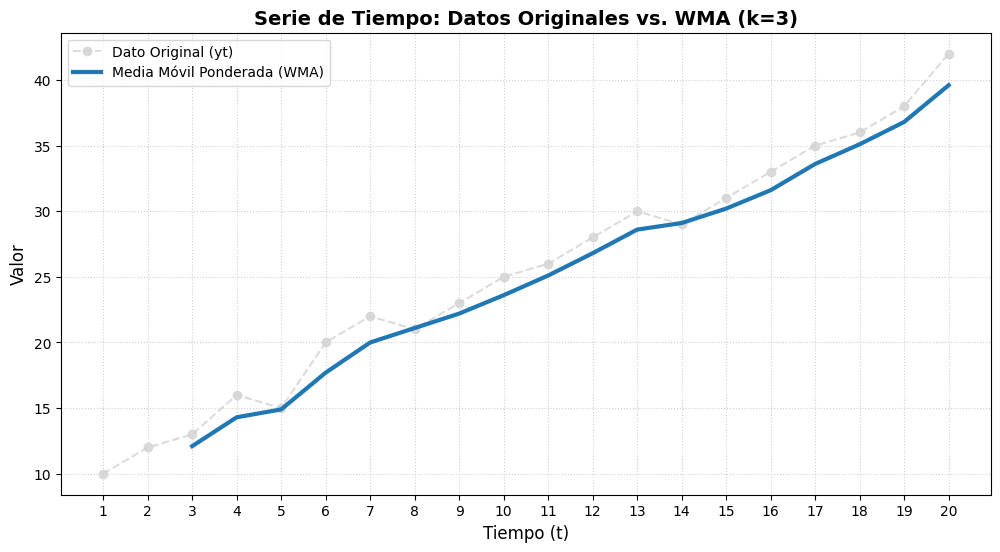

In [ ]:
# ... (tu código anterior se mantiene igual hasta el cálculo de wma_vals)

# 1. Configurar el tamaño de la gráfica
plt.figure(figsize=(12, 6))

# 2. Graficar Datos Originales (Puntos y línea gris)
plt.plot(df['Tiempo (t)'], df['Dato (yt)'],
         label='Dato Original (yt)',
         marker='o',
         linestyle='--',
         color='lightgray',
         alpha=0.8)

# 3. Graficar WMA (Línea azul sólida)
# Usamos wma_vals porque contiene los números (wma_vals tiene NaN al inicio, lo cual es correcto para graficar)
plt.plot(df['Tiempo (t)'], wma_vals,
         label='Media Móvil Ponderada (WMA)',
         color='#1f77b4',
         linewidth=3)

# 4. Personalización estética
plt.title('Serie de Tiempo: Datos Originales vs. WMA (k=3)', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo (t)', fontsize=12)
plt.ylabel('Valor', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 5. Ajustar los límites del eje X para que coincida con tus datos
plt.xticks(df['Tiempo (t)'])

# Mostrar la gráfica
plt.show()